# 600-concept WordNet steerability analysis (run 009)

Data: STAGE7 main run — llama-3.1-8B, v2b frames, all-layer K=1, coefs 0.5–0.8,
gpt-oss judge, evaluations **V1** (subject-invite) + **V6** (neutral).
Outcome `steered` = V1 ∪ V6. Predictors: per-concept spectral stats from the AGOP
(median across the 31 layers), plus lexical covariates from the dataset csv.

Sections: (1) load & merge, (2) V1–V6 agreement, (3) steered-vs-not boxplots,
(4) logistic regressions with AIC ladder + mixed-effects check.

In [1]:
import pickle, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
TAG = "Lall_K1ev_def_fv2b"
CSV1 = f"csvs/rfm_wordnet_gpt_oss_outputs_500_concepts_llama_3.1_8B_english_only_{TAG}.csv"
CSV6 = f"csvs/rfm_wordnet_gpt_oss_outputs_500_concepts_llama_3.1_8B_english_only_v6_{TAG}.csv"
STATS_DIR = "directions_wordnet_fv2b" 

In [2]:
# --- load judgments + dataset covariates ---
v1 = pd.read_csv(CSV1, header=0, names=["concept", "s_v1"])
v6 = pd.read_csv(CSV6, header=0, names=["concept", "s_v6"])
ds = pd.read_csv("bbxdata/bbx_wordnet_ds.csv")
df = ds.merge(v1, on="concept").merge(v6, on="concept")
df["steered"] = ((df.s_v1 + df.s_v6) > 0).astype(int)
print(len(df), "concepts;  V1:", df.s_v1.sum(), " V6:", df.s_v6.sum(),
      " union:", df.steered.sum(), f"({df.steered.mean():.1%})")
df.head(3)

600 concepts;  V1: 81  V6: 95  union: 119 (19.8%)


,concept,supersense,zipf,conc,aoa,polysemy,n_tokens,is_instance,n_verb_senses,s_v1,s_v6,steered
0,infliction,noun.act,2.37,2.12,12.00,3,2,False,0,0,0,0
1,redeye,noun.act,2.27,3.77,10.38,1,2,False,0,0,0,0
2,downshift,noun.act,1.97,3.30,12.74,2,2,False,0,0,0,0


In [3]:
# --- per-concept spectral stats: median across layers of the AGOP eigen-metrics ---
def spectral_row(concept):
    f = f"{STATS_DIR}/rfm_{concept}_llama_3_8b_it_eng_only_rfmstats.pkl"
    d = pickle.load(open(f, "rb"))
    lyrs = sorted(d.keys())
    mid = lyrs[len(lyrs) * 2 // 5]  # ~40% depth, the pilot's single-layer choice
    med = lambda k: float(np.median([d[l][k] for l in lyrs]))
    return dict(concept=concept,
                l1_tr=med("frac1"), l1_l2=med("frac2"), pr=med("pr"), val_r=med("val_r"),
                l1_tr_mid=d[mid]["frac1"], l1_l2_mid=d[mid]["frac2"])

spec = pd.DataFrame([spectral_row(c) for c in df.concept])
df = df.merge(spec, on="concept")
df[["l1_tr", "l1_l2", "pr", "val_r"]].describe().round(3)

,l1_tr,l1_l2,pr,val_r
count,600.000,600.000,600.000,600.000
mean,0.536,1.983,2.520,0.865
std,0.050,0.539,0.235,0.089
min,0.441,1.277,1.780,0.375
25%,0.502,1.646,2.355,0.837
50%,0.528,1.826,2.501,0.885
75%,0.563,2.144,2.677,0.914
max,0.733,5.563,3.132,0.995


## V1–V6 agreement

Both evaluations judge the *same* directions on different generation prompts, so their
agreement bounds how much of "steerability" is prompt-independent.

In [4]:
ct = pd.crosstab(df.s_v1, df.s_v6, margins=True)
phi = stats.pearsonr(df.s_v1, df.s_v6)  # phi coefficient == Pearson on binaries
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(df.s_v1, df.s_v6)
jacc = (df.s_v1 & df.s_v6).sum() / (df.s_v1 | df.s_v6).sum()
print(ct)
print(f"\nphi = {phi.statistic:.3f} (p={phi.pvalue:.2g})   Cohen kappa = {kappa:.3f}   Jaccard = {jacc:.3f}")

s_v6    0   1  All
s_v1              
0     481  38  519
1      24  57   81
All   505  95  600

phi = 0.590 (p=1.4e-57)   Cohen kappa = 0.588   Jaccard = 0.479


## Steered vs non-steered: distributions

Boxplots of each candidate predictor split by the union outcome. Mann–Whitney U
p-value (two-sided) in each panel title.

/var/folders/w4/9kj7pk5142g7k8nyg5l36qyh0000gn/T/ipykernel_51345/1667986058.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["not steered", "steered"])
/var/folders/w4/9kj7pk5142g7k8nyg5l36qyh0000gn/T/ipykernel_51345/1667986058.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["not steered", "steered"])
/var/folders/w4/9kj7pk5142g7k8nyg5l36qyh0000gn/T/ipykernel_51345/1667986058.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["not steered", "steered"])
/var/folders/w4/9kj7pk5142g7k8nyg5l36qyh0000gn/T/ipykernel_51345/1667986058.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_

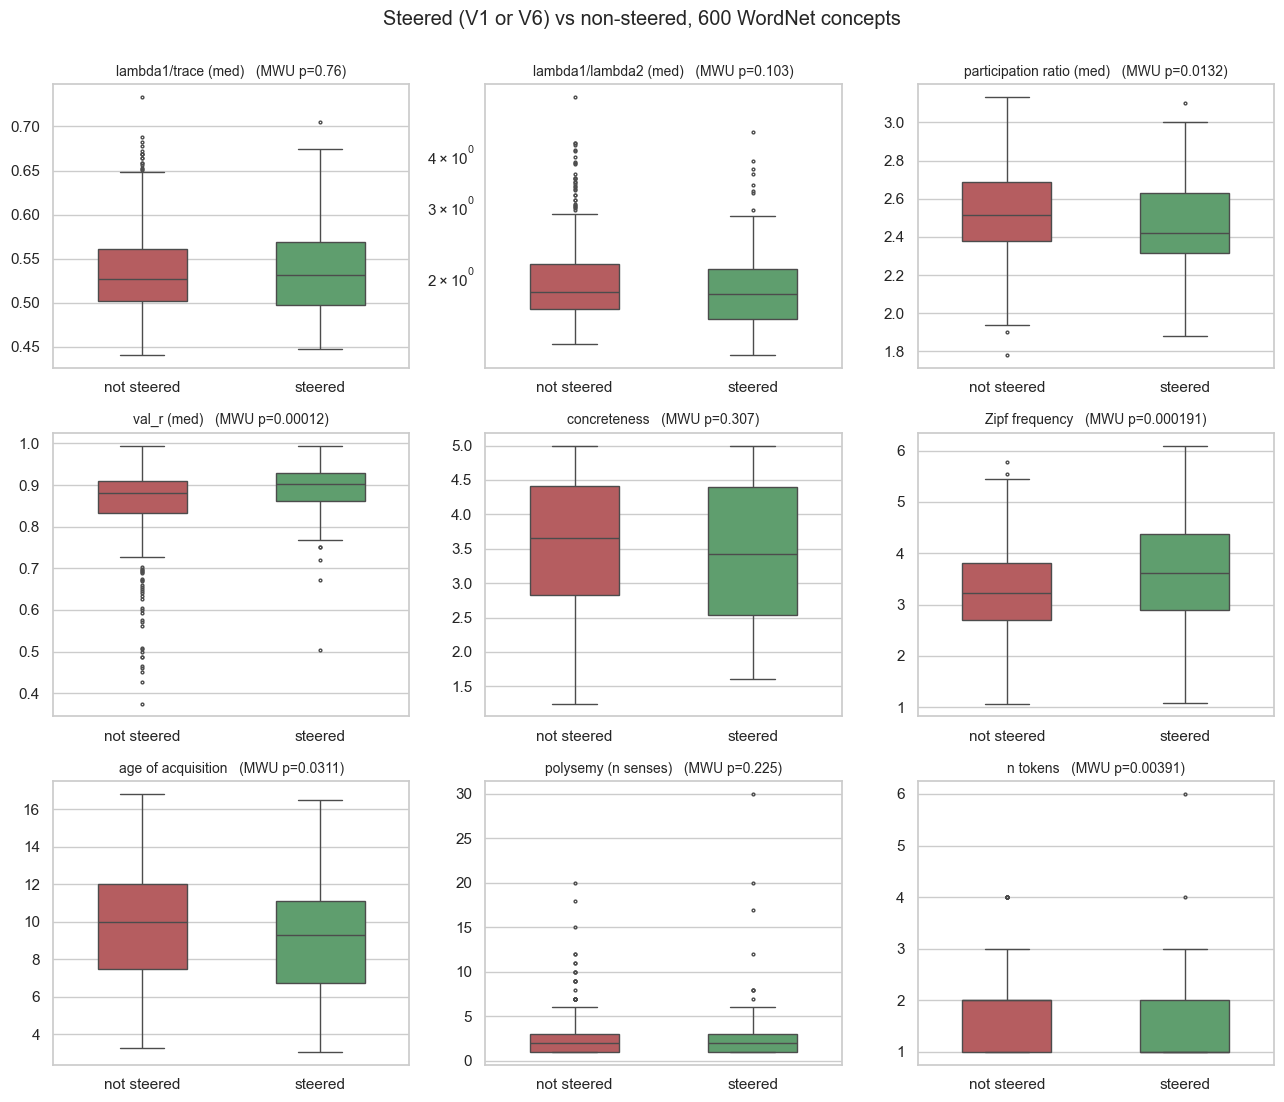

In [5]:
VARS = [("l1_tr", "lambda1/trace (med)"), ("l1_l2", "lambda1/lambda2 (med)"),
        ("pr", "participation ratio (med)"), ("val_r", "val_r (med)"),
        ("conc", "concreteness"), ("zipf", "Zipf frequency"),
        ("aoa", "age of acquisition"), ("polysemy", "polysemy (n senses)"),
        ("n_tokens", "n tokens")]
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for ax, (v, label) in zip(axes.flat, VARS):
    sns.boxplot(data=df, x="steered", y=v, hue="steered", ax=ax,
                palette=["#c44e52", "#55a868"], legend=False, width=.5, fliersize=2)
    u = stats.mannwhitneyu(df.loc[df.steered == 0, v], df.loc[df.steered == 1, v])
    ax.set_title(f"{label}   (MWU p={u.pvalue:.3g})", fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticklabels(["not steered", "steered"])
    if v == "l1_l2": ax.set_yscale("log")
fig.suptitle("Steered (V1 or V6) vs non-steered, 600 WordNet concepts", y=1.0)
fig.tight_layout()
fig.savefig("plots/steered_boxplots_600.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# point-biserial correlations with the union outcome, sorted
rows = []
for v, label in VARS:
    r = stats.pointbiserialr(df.steered, df[v])
    rows.append((label, r.statistic, r.pvalue))
pd.DataFrame(rows, columns=["variable", "r_pb", "p"]).sort_values("r_pb", key=abs,
                                                                  ascending=False).round(4)

,variable,r_pb,p
5,Zipf frequency,0.1575,0.0001
3,val_r (med),0.1424,0.0005
6,age of acquisition,-0.0963,0.0183
8,n tokens,-0.0932,0.0224
2,participation ratio (med),-0.0859,0.0355
7,polysemy (n senses),0.0701,0.0865
4,concreteness,-0.0451,0.2696
1,lambda1/lambda2 (med),-0.0402,0.3251
0,lambda1/trace (med),0.0211,0.6063


## Steerability by supersense

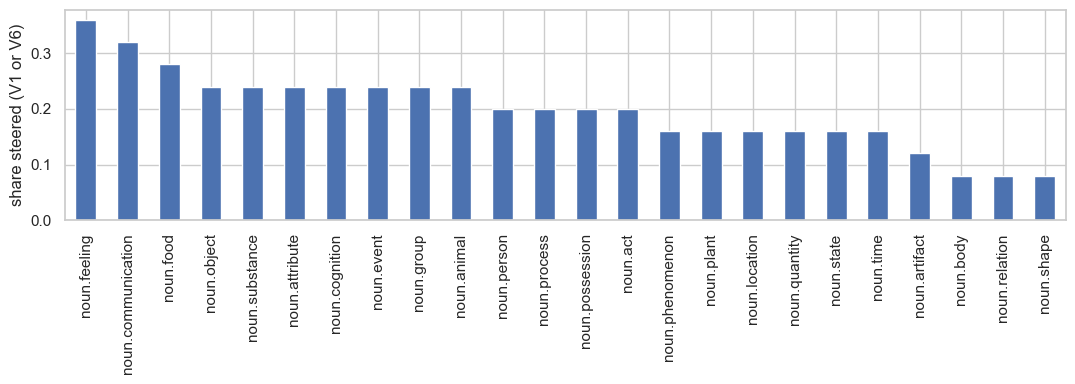

supersense,noun.feeling,noun.communication,noun.food,noun.object,noun.substance,noun.attribute,noun.cognition,noun.event,noun.group,noun.animal,...,noun.phenomenon,noun.plant,noun.location,noun.quantity,noun.state,noun.time,noun.artifact,noun.body,noun.relation,noun.shape
steered_n,9.000,8.000000,7.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,2.000000,2.000000
n,25.000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,...,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
l1_tr,0.509,0.522266,0.557807,0.528163,0.512849,0.515363,0.512657,0.541691,0.528904,0.519791,...,0.518468,0.553797,0.542692,0.514188,0.517125,0.516934,0.542157,0.548078,0.502412,0.544665


In [7]:
ss = df.groupby("supersense").agg(steered_n=("steered", "sum"), n=("steered", "count"),
                                 l1_tr=("l1_tr", "median")).sort_values("steered_n", ascending=False)
fig, ax = plt.subplots(figsize=(11, 4))
(ss.steered_n / ss.n).plot.bar(ax=ax, color="#4c72b0")
ax.set_ylabel("share steered (V1 or V6)"); ax.set_xlabel("")
fig.tight_layout(); fig.savefig("plots/steered_by_supersense_600.png", dpi=150, bbox_inches="tight")
plt.show()
ss.T

## Regressions: steerability ~ supersense + covariates

Outcome is binary, observations are grouped 25-per-supersense, so the proper model is a
**mixed-effects logistic regression** with a random intercept per supersense. statsmodels'
Bayesian mixed GLM does not report AIC, so model comparison uses the **fixed-effects logit
AIC ladder** (supersense as fixed dummies), with the mixed model as a robustness check on
the covariate coefficients. Continuous predictors are z-scored.

In [8]:
ZVARS = ["l1_tr", "l1_l2", "pr", "conc", "zipf", "aoa", "polysemy", "n_tokens"]
for v in ZVARS:
    df["z_" + v] = (df[v] - df[v].mean()) / df[v].std()
zterms = " + ".join("z_" + v for v in ZVARS)
lex = " + ".join("z_" + v for v in ["conc", "zipf", "aoa", "polysemy", "n_tokens"])
spec_t = " + ".join("z_" + v for v in ["l1_tr", "l1_l2", "pr"])

models = {
    "M0 null":                 "steered ~ 1",
    "M1 lexical":              f"steered ~ {lex}",
    "M2 spectral":             f"steered ~ {spec_t}",
    "M3 lexical+spectral":     f"steered ~ {zterms}",
    "M4 supersense":           "steered ~ C(supersense)",
    "M5 supersense+lexical":   f"steered ~ C(supersense) + {lex}",
    "M6 supersense+all":       f"steered ~ C(supersense) + {zterms}",
}
rows = []
fits = {}
for name, fml in models.items():
    m = smf.logit(fml, data=df).fit(disp=0)
    fits[name] = m
    rows.append((name, m.df_model, round(m.aic, 1), round(m.llf, 1),
                 round(m.prsquared, 3)))
pd.DataFrame(rows, columns=["model", "df", "AIC", "logLik", "McFadden R2"])

,model,df,AIC,logLik,McFadden R2
0,M0 null,0.0,599.7,-298.8,0.000
1,M1 lexical,5.0,591.3,-289.6,0.031
2,M2 spectral,3.0,594.4,-293.2,0.019
3,M3 lexical+spectral,8.0,576.7,-279.4,0.065
4,M4 supersense,23.0,626.7,-289.3,0.032
5,M5 supersense+lexical,28.0,615.8,-278.9,0.067
6,M6 supersense+all,31.0,597.9,-267.0,0.107


In [9]:
best = min(fits, key=lambda k: fits[k].aic)
print("Lowest AIC:", best)
m = fits["M6 supersense+all"]
coefs = m.summary2().tables[1]
coefs[~coefs.index.str.startswith("C(")].round(3)  # covariates (supersense dummies suppressed)

Lowest AIC: M3 lexical+spectral


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-1.673,0.534,-3.129,0.002,-2.720,-0.625
z_l1_tr,-0.289,0.412,-0.703,0.482,-1.096,0.517
z_l1_l2,-0.484,0.279,-1.734,0.083,-1.031,0.063
z_pr,-0.876,0.291,-3.012,0.003,-1.446,-0.306
z_conc,-0.464,0.169,-2.749,0.006,-0.795,-0.133
z_zipf,0.435,0.185,2.353,0.019,0.073,0.797
z_aoa,-0.167,0.151,-1.106,0.269,-0.462,0.129
z_polysemy,0.077,0.115,0.665,0.506,-0.150,0.303
z_n_tokens,0.022,0.161,0.137,0.891,-0.293,0.337


In [10]:
# mixed-effects logistic (random intercept per supersense) as robustness check
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
mm = BinomialBayesMixedGLM.from_formula(
    f"steered ~ {zterms}", {"ss": "0 + C(supersense)"}, df).fit_vb()
me = pd.DataFrame({"post_mean": mm.fe_mean, "post_sd": mm.fe_sd}, index=mm.model.exog_names)
me["z"] = me.post_mean / me.post_sd
print("random-intercept SD (supersense):", round(float(np.exp(mm.vcp_mean[0])), 3))
me.round(3)

random-intercept SD (supersense): 0.29


,post_mean,post_sd,z
Intercept,-1.565,0.107,-14.665
z_l1_tr,-0.173,0.111,-1.567
z_l1_l2,-0.483,0.116,-4.161
z_pr,-0.737,0.113,-6.555
z_conc,-0.453,0.105,-4.331
z_zipf,0.351,0.103,3.412
z_aoa,-0.176,0.105,-1.681
z_polysemy,0.072,0.096,0.749
z_n_tokens,0.017,0.110,0.154


## Notes

- *(fill in after inspection)* which predictors survive supersense controls;
  whether spectral stats add anything beyond category membership (M5 vs M6 AIC);
  and how the mixed-model covariate signs compare to the fixed-effects logit.